Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Upload an image file (e.g., .jpg, .png, .avif) to process.


Saving nationalherald_2024-11-30_z2kk3i3r_2024113074F.jpg to nationalherald_2024-11-30_z2kk3i3r_2024113074F.jpg
Processing image from: /content/nationalherald_2024-11-30_z2kk3i3r_2024113074F.jpg
[System] Displaying uploaded image...


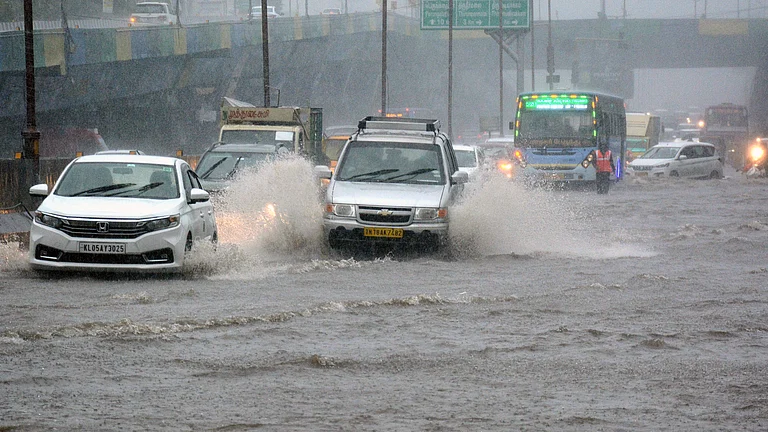


[System] Starting rescue operation cycle for image...
[PerceptionAgent] Processing image...
[PerceptionAgent] YOLOv8 detected 1 people with confidence >= 0.3
[PerceptionAgent] Displaying image with YOLO detections...


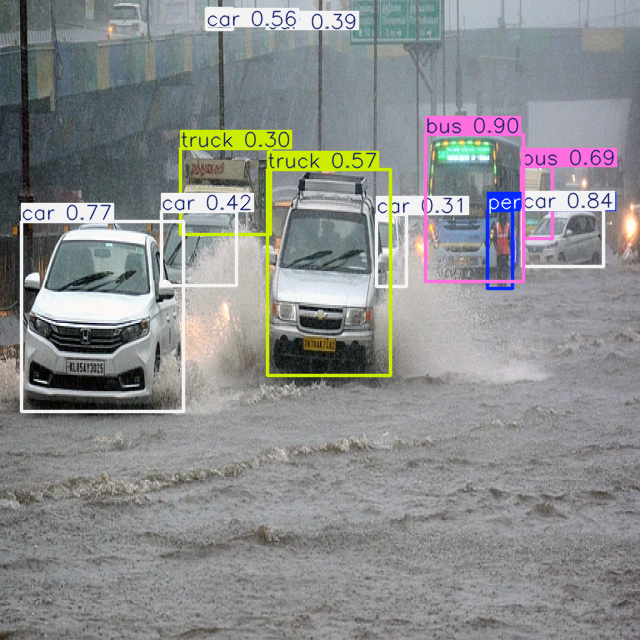

[AnalysisAgent] Analyzing data...
[AnalysisAgent] Risk Level: Moderate, Rescue Priority: False
[PlanningAgent] Creating rescue plan...
[PlanningAgent] Plan: Deploy 1 boat
[ExecutionAgent] Executing plan: Deploy 1 boat
[CommunicationAgent] Broadcasting rescue update...
[CommunicationAgent] Message: Rescue successful. Teams in place.
[LearningAgent] Updating models based on new data...
[LearningAgent] Logging: {'flood_detected': np.True_, 'water_level': np.float64(2.72), 'people_detected': 1}, {'risk_level': 'Moderate', 'rescue_priority': False}, {'execution_success': True}
[LearningAgent] Model updated with new experience.
[System] Image processing complete.


In [ ]:
# Mount Google Drive if your image is there (optional)
from google.colab import drive
drive.mount('/content/drive')

# Install required dependencies
!pip install pillow-avif-plugin
!pip install ultralytics

# Import required libraries
from abc import ABC, abstractmethod
import random
import cv2
import numpy as np
import os
from PIL import Image
import pillow_avif
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

# --- Abstract Base Agent Class ---
class Agent(ABC):
    @abstractmethod
    def run(self, *args, **kwargs):
        pass

# --- Perception Agent ---
class PerceptionAgent(Agent):
    def __init__(self):
        self.model = YOLO('yolov8m.pt')  # Use medium model for better accuracy

    def run(self, frame):
        print(f"[PerceptionAgent] Processing image...")

        if frame is None:
            raise ValueError("Invalid image received")

        if len(frame.shape) != 3 or frame.shape[2] != 3:
            raise ValueError("Image must be a 3-channel color image (BGR)")

        # Resize image for consistent YOLO input
        image = cv2.resize(frame, (640, 640), interpolation=cv2.INTER_AREA)

        # Mock water level estimation
        water_level = round((np.mean(image[:, :, 0]) / 255) * 5, 2)
        flood_detected = water_level > 2.0

        try:
            results = self.model(image, verbose=False, conf=0.3, iou=0.5)
            people_detected = sum(1 for r in results[0].boxes if int(r.cls) == 0)
            print(f"[PerceptionAgent] YOLOv8 detected {people_detected} people with confidence >= 0.3")
            annotated_frame = results[0].plot()
            print("[PerceptionAgent] Displaying image with YOLO detections...")
            cv2_imshow(annotated_frame)
        except Exception as e:
            print(f"[PerceptionAgent] YOLOv8 inference failed: {str(e)}. Using default people count.")
            people_detected = 0

        return {
            "flood_detected": flood_detected,
            "water_level": water_level,
            "people_detected": people_detected
        }

# --- Analysis Agent ---
class AnalysisAgent(Agent):
    def run(self, perception_data):
        print("[AnalysisAgent] Analyzing data...")
        risk_level = "High" if perception_data['water_level'] > 3.0 else "Moderate"
        rescue_priority = perception_data['people_detected'] > 5  # Lowered threshold
        print(f"[AnalysisAgent] Risk Level: {risk_level}, Rescue Priority: {rescue_priority}")
        return {
            "risk_level": risk_level,
            "rescue_priority": rescue_priority
        }

# --- Planning Agent ---
class PlanningAgent(Agent):
    def run(self, analysis_data):
        print("[PlanningAgent] Creating rescue plan...")
        if analysis_data['rescue_priority']:
            plan = "Deploy 3 boats and 2 drones"
        else:
            plan = "Deploy 1 boat"
        print(f"[PlanningAgent] Plan: {plan}")
        return {"rescue_plan": plan}

# --- Execution Agent ---
class ExecutionAgent(Agent):
    def run(self, plan):
        print(f"[ExecutionAgent] Executing plan: {plan['rescue_plan']}")
        success = True
        return {"execution_success": success}

# --- Communication Agent ---
class CommunicationAgent(Agent):
    def run(self, execution_result):
        print("[CommunicationAgent] Broadcasting rescue update...")
        if execution_result['execution_success']:
            msg = "Rescue successful. Teams in place."
        else:
            msg = "Rescue attempt failed. Replanning required."
        print(f"[CommunicationAgent] Message: {msg}")
        return msg

# --- Learning Agent ---
class LearningAgent(Agent):
    def run(self, perception_data, analysis_data, execution_result):
        print("[LearningAgent] Updating models based on new data...")
        print(f"[LearningAgent] Logging: {perception_data}, {analysis_data}, {execution_result}")
        print("[LearningAgent] Model updated with new experience.")

# --- Main Controller ---
class DisasterRescueAI:
    def __init__(self):
        self.perception = PerceptionAgent()
        self.analysis = AnalysisAgent()
        self.planning = PlanningAgent()
        self.execution = ExecutionAgent()
        self.communication = CommunicationAgent()
        self.learning = LearningAgent()

    def run_cycle(self, frame):
        print("\n[System] Starting rescue operation cycle for image...")
        perception_data = self.perception.run(frame)
        analysis_data = self.analysis.run(perception_data)
        plan = self.planning.run(analysis_data)
        execution_result = self.execution.run(plan)
        self.communication.run(execution_result)
        self.learning.run(perception_data, analysis_data, execution_result)

# --- Main execution block ---
if __name__ == "__main__":
    print("Upload an image file (e.g., .jpg, .png, .avif) to process.")
    uploaded = files.upload()

    if not uploaded:
        print("Error: No file uploaded. Please upload an image file.")
    else:
        image_filename = list(uploaded.keys())[0]
        image_path = os.path.join("/content", image_filename)

        image_extensions = ('.jpg', '.jpeg', '.png', '.avif', '.webp')
        if not image_path.lower().endswith(image_extensions):
            print(f"Error: Unsupported file format. Please upload an image file ({image_extensions}).")
        else:
            print(f"Processing image from: {image_path}")
            try:
                frame = cv2.imread(image_path, cv2.IMREAD_COLOR)
                if frame is None:
                    print("[System] OpenCV failed to load image. Trying Pillow for AVIF and WebP support...")
                    try:
                        pil_image = Image.open(image_path)
                        frame = np.array(pil_image.convert("RGB"))
                        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                    except Exception as e:
                        print(f"Error loading image with Pillow: {str(e)}")
                        exit()

                print("[System] Displaying uploaded image...")
                cv2_imshow(frame)

                system = DisasterRescueAI()
                system.run_cycle(frame)
                print("[System] Image processing complete.")

            except Exception as e:
                print(f"Error during image processing: {str(e)}")

Fire Res


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload an image file (e.g., .jpg, .png, .avif) to process.


Saving images (1).jpeg to images (1).jpeg
Processing image from: /content/images (1).jpeg
[System] Displaying uploaded image...


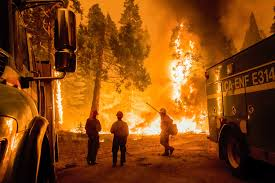


[System] Starting fire rescue operation cycle for image...
[PerceptionAgent] Processing image for fire detection...
[PerceptionAgent] YOLOv8 detected 2 people with confidence >= 0.3
[PerceptionAgent] Displaying image with YOLO detections...


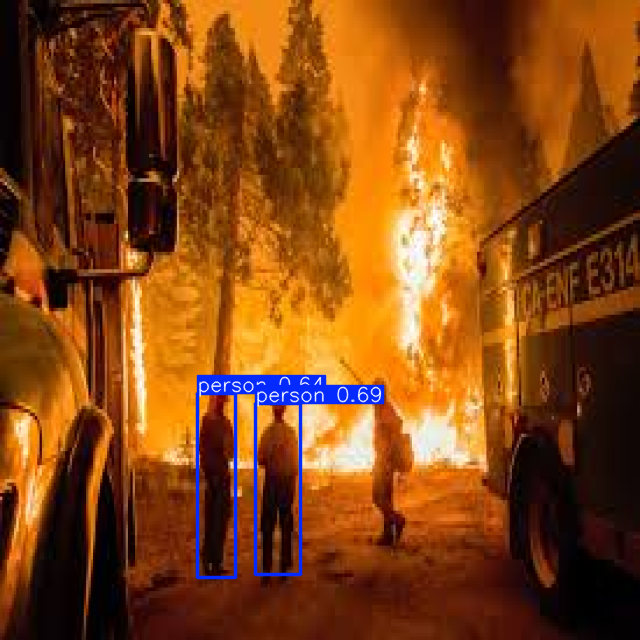

[AnalysisAgent] Analyzing data...
[AnalysisAgent] Risk Level: High, Rescue Priority: True
[PlanningAgent] Creating rescue plan...
[PlanningAgent] Plan: Deploy 3 fire trucks and 2 helicopters
[ExecutionAgent] Executing plan: Deploy 3 fire trucks and 2 helicopters
[CommunicationAgent] Broadcasting rescue update...
[CommunicationAgent] Message: Rescue successful. Firefighting teams in place.
[LearningAgent] Updating models based on new data...
[LearningAgent] Logging: {'fire_detected': np.True_, 'fire_severity': np.float64(4.02), 'people_detected': 2}, {'risk_level': 'High', 'rescue_priority': np.True_}, {'execution_success': True}
[LearningAgent] Model updated with new experience.
[System] Image processing complete.


In [ ]:
# Mount Google Drive if your image is there (optional)
from google.colab import drive
drive.mount('/content/drive')

# Install required dependencies
!pip install pillow-avif-plugin
!pip install ultralytics

# Import required libraries
from abc import ABC, abstractmethod
import cv2
import numpy as np
import os
from PIL import Image
import pillow_avif
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

# --- Abstract Base Agent Class ---
class Agent(ABC):
    @abstractmethod
    def run(self, *args, **kwargs):
        pass

# --- Perception Agent ---
class PerceptionAgent(Agent):
    def __init__(self):
        self.model = YOLO('yolov8m.pt')

    def run(self, frame):
        print(f"[PerceptionAgent] Processing image for fire detection...")

        if frame is None:
            raise ValueError("Invalid image received")

        if len(frame.shape) != 3 or frame.shape[2] != 3:
            raise ValueError("Image must be a 3-channel color image (BGR)")

        image = cv2.resize(frame, (640, 640), interpolation=cv2.INTER_AREA)

        # Estimate fire presence based on red/orange color dominance in the image
        hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        # Define range for red/orange hues (fire-like colors)
        lower_fire = np.array([0, 50, 50])
        upper_fire = np.array([30, 255, 255])
        fire_mask = cv2.inRange(hsv_image, lower_fire, upper_fire)
        fire_ratio = np.sum(fire_mask) / (640 * 640 * 255)  # Normalize by image size
        fire_detected = fire_ratio > 0.1  # Threshold for fire detection
        fire_severity = round(fire_ratio * 5, 2)  # Scale to 0-5 for severity

        try:
            results = self.model(image, verbose=False, conf=0.3, iou=0.5)
            people_detected = sum(1 for r in results[0].boxes if int(r.cls) == 0)
            print(f"[PerceptionAgent] YOLOv8 detected {people_detected} people with confidence >= 0.3")
            annotated_frame = results[0].plot()
            print("[PerceptionAgent] Displaying image with YOLO detections...")
            cv2_imshow(annotated_frame)
        except Exception as e:
            print(f"[PerceptionAgent] YOLOv8 inference failed: {str(e)}. Using default people count.")
            people_detected = 0

        return {
            "fire_detected": fire_detected,
            "fire_severity": fire_severity,
            "people_detected": people_detected
        }

# --- Analysis Agent ---
class AnalysisAgent(Agent):
    def run(self, perception_data):
        print("[AnalysisAgent] Analyzing data...")
        risk_level = "High" if perception_data['fire_severity'] > 3.0 else "Moderate" if perception_data['fire_severity'] > 1.0 else "Low"
        # Set rescue_priority to True if fire is severe or many people are detected
        rescue_priority = (perception_data['fire_severity'] > 2.0 or perception_data['people_detected'] > 5)
        print(f"[AnalysisAgent] Risk Level: {risk_level}, Rescue Priority: {rescue_priority}")
        return {
            "risk_level": risk_level,
            "rescue_priority": rescue_priority
        }

# --- Planning Agent ---
class PlanningAgent(Agent):
    def run(self, analysis_data):
        print("[PlanningAgent] Creating rescue plan...")
        if analysis_data['rescue_priority']:
            if analysis_data['risk_level'] == "High":
                plan = "Deploy 3 fire trucks and 2 helicopters"
            elif analysis_data['risk_level'] == "Moderate":
                plan = "Deploy 1 fire truck and 1 drone"
            else:
                plan = "Deploy 1 fire truck"
        else:
            plan = "No rescue plan required. Situation under control."
        print(f"[PlanningAgent] Plan: {plan}")
        return {"rescue_plan": plan}

# --- Execution Agent ---
class ExecutionAgent(Agent):
    def run(self, plan):
        if plan['rescue_plan'] != "No rescue plan required. Situation under control.":
            print(f"[ExecutionAgent] Executing plan: {plan['rescue_plan']}")
            success = True
            return {"execution_success": success}
        return {"execution_success": None}

# --- Communication Agent ---
class CommunicationAgent(Agent):
    def run(self, execution_result):
        print("[CommunicationAgent] Broadcasting rescue update...")
        if execution_result.get('execution_success') is True:
            msg = "Rescue successful. Firefighting teams in place."
        elif execution_result.get('execution_success') is False:
            msg = "Rescue attempt failed. Replanning required."
        else:
            msg = "No rescue action taken. Situation monitored."
        print(f"[CommunicationAgent] Message: {msg}")
        return msg

# --- Learning Agent ---
class LearningAgent(Agent):
    def run(self, perception_data, analysis_data, execution_result):
        print("[LearningAgent] Updating models based on new data...")
        print(f"[LearningAgent] Logging: {perception_data}, {analysis_data}, {execution_result}")
        print("[LearningAgent] Model updated with new experience.")

# --- Main Controller ---
class FireRescueAI:
    def __init__(self):
        self.perception = PerceptionAgent()
        self.analysis = AnalysisAgent()
        self.planning = PlanningAgent()
        self.execution = ExecutionAgent()
        self.communication = CommunicationAgent()
        self.learning = LearningAgent()

    def run_cycle(self, frame):
        print("\n[System] Starting fire rescue operation cycle for image...")
        perception_data = self.perception.run(frame)
        analysis_data = self.analysis.run(perception_data)
        plan = self.planning.run(analysis_data)
        execution_result = self.execution.run(plan)
        self.communication.run(execution_result)
        self.learning.run(perception_data, analysis_data, execution_result)

# --- Main execution block ---
if __name__ == "__main__":
    print("Upload an image file (e.g., .jpg, .png, .avif) to process.")
    uploaded = files.upload()

    if not uploaded:
        print("Error: No file uploaded. Please upload an image file.")
    else:
        image_filename = list(uploaded.keys())[0]
        image_path = os.path.join("/content", image_filename)

        image_extensions = ('.jpg', '.jpeg', '.png', '.avif', '.webp')
        if not image_path.lower().endswith(image_extensions):
            print(f"Error: Unsupported file format. Please upload an image file ({image_extensions}).")
        else:
            print(f"Processing image from: {image_path}")
            try:
                frame = cv2.imread(image_path, cv2.IMREAD_COLOR)
                if frame is None:
                    print("[System] OpenCV failed to load image. Trying Pillow for AVIF and WebP support...")
                    try:
                        pil_image = Image.open(image_path)
                        frame = np.array(pil_image.convert("RGB"))
                        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                    except Exception as e:
                        print(f"Error loading image with Pillow: {str(e)}")
                        exit()

                print("[System] Displaying uploaded image...")
                cv2_imshow(frame)

                system = FireRescueAI()
                system.run_cycle(frame)
                print("[System] Image processing complete.")

            except Exception as e:
                print(f"Error during image processing: {str(e)}")
